---
<a id='módulo-04'></a>

# 📊 MÓDULO 04 — Visualización del Mercado Laboral (v4.0)

> **Versión corregida:** sin datos sintéticos, conectado al pipeline real,
> con heatmaps legibles, gráfico de salario por rol corregido,
> y nuevo heatmap de co-ocurrencia de skills.


# 📊 04 — Análisis y Visualización del Mercado Laboral Tech en España
**DataTalent Solutions S.L. · v4.0**  
**Fuente:** datos reales generados por `02_cleaning.ipynb` y `03_eda.ipynb`

---

| Bloque | Contenido |
|--------|-----------|
| 0 | Configuración y carga de datos del pipeline |
| 1 | Distribución y volumen de vacantes |
| 2 | Análisis retributivo y salarial |
| 3 | Mapas de calor y correlaciones (incl. co-ocurrencia de skills) |
| 4 | Stack tecnológico y brecha Used vs Wanted |
| 5 | Análisis estadístico avanzado |
| 6 | Visualizaciones interactivas (Plotly) |
| 7 | Resumen ejecutivo y KPIs |

> **Requisito:** ejecutar primero `02_cleaning.ipynb` y `03_eda.ipynb`.  
> Archivos necesarios en `data/clean/` y `data/eda/`.


## ⚙️ Bloque 0 — Configuración e importaciones

In [ ]:
# Instalación de dependencias (Google Colab)
import subprocess, sys

for pkg, imp in [("squarify", "squarify"), ("statsmodels", "statsmodels"),
                  ("plotly", "plotly"), ("kaleido", "kaleido")]:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✅ Dependencias verificadas.")


✅ Dependencias verificadas.


In [ ]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from IPython.display import display

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    sm = None; HAS_STATSMODELS = False

try:
    import squarify
    HAS_SQUARIFY = True
except ImportError:
    HAS_SQUARIFY = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Rutas del proyecto ──
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"
DATA_EDA   = PROJECT_ROOT / "data" / "eda"
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

# ── Paleta corporativa ──
PAL = {
    "primary":   "#1A365D",
    "secondary": "#2B6CB0",
    "accent":    "#4299E1",
    "warm":      "#ED8936",
    "success":   "#48BB78",
    "light":     "#EBF8FF",
}
CMAP_MAIN = LinearSegmentedColormap.from_list("dt", [PAL["light"], PAL["secondary"], PAL["primary"]])

sns.set_theme(style="whitegrid", palette=list(PAL.values()))
plt.rcParams.update({
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 14,
    "axes.titleweight": "bold", "figure.titlesize": 17,
    "figure.titleweight": "bold", "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#FAFAFA",
})

print("✅ Entorno configurado.")
print(f"📁 Raíz: {PROJECT_ROOT}")
print(f"📂 data/clean: {DATA_CLEAN}  |  data/eda: {DATA_EDA}")
print(f"🖼️  images: {IMAGES_DIR}")


✅ Entorno configurado.
📁 Raíz: /content
📂 data/clean: /content/data/clean  |  data/eda: /content/data/eda
🖼️  images: /content/images


### 📥 Carga de datos reales

Todos los datos provienen del pipeline `02_cleaning.ipynb` → `03_eda.ipynb`.  
**No se generan datos sintéticos.** Si falta algún archivo, la celda muestra el error exacto y qué notebook hay que ejecutar primero.

| Archivo | Origen | Descripción |
|---------|--------|-------------|
| `jobs_eda.csv` | `data/eda/` | Dataset principal post-EDA (preferido) |
| `jobs_all_clean.csv` | `data/clean/` | Dataset unificado post-cleaning (fallback) |
| `technology_rankings_used_eda.csv` / `_used.csv` | eda / clean | Rankings Stack Overflow usadas |
| `technology_rankings_wanted_eda.csv` / `_wanted.csv` | eda / clean | Rankings Stack Overflow demandadas |
| `job_skills_long.csv` | `data/clean/` | Skills en formato largo (co-ocurrencia) |


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CARGA DE DATOS REALES — sin datos sintéticos
# ─────────────────────────────────────────────────────────────────

def load_first(candidates, label):
    for p in candidates:
        if Path(p).exists():
            df = pd.read_csv(p)
            print(f"  ✅ {label:45s} ← {Path(p).name}  ({df.shape[0]:,} filas × {df.shape[1]} cols)")
            return df, Path(p)
    lines = "\n  ".join(str(p) for p in candidates)
    raise FileNotFoundError(
        f"\n❌ No se encontró '{label}'.\n  Buscado en:\n  {lines}"
        "\n\n👉 Ejecuta primero 02_cleaning.ipynb (y opcionalmente 03_eda.ipynb)."
    )

print("📂 Cargando archivos del pipeline...")

df, JOBS_PATH = load_first(
    [DATA_EDA / "jobs_eda.csv", DATA_CLEAN / "jobs_all_clean.csv"],
    "Dataset principal de ofertas"
)
POST_EDA = (JOBS_PATH.parent == DATA_EDA)

df_used, _ = load_first(
    [DATA_EDA / "technology_rankings_used_eda.csv", DATA_CLEAN / "technology_rankings_used.csv"],
    "Rankings tecnologías usadas (Stack Overflow)"
)
df_wanted, _ = load_first(
    [DATA_EDA / "technology_rankings_wanted_eda.csv", DATA_CLEAN / "technology_rankings_wanted.csv"],
    "Rankings tecnologías demandadas (Stack Overflow)"
)

try:
    df_skills, _ = load_first(
        [DATA_EDA / "job_skills_long_eda.csv", DATA_CLEAN / "job_skills_long.csv"],
        "Skills en formato largo"
    )
    HAS_SKILLS = True
except FileNotFoundError as e:
    print(f"  ⚠️  {e}\n     El heatmap de co-ocurrencia no estará disponible.")
    df_skills = None; HAS_SKILLS = False

# ── Normalización de columnas clave ──
# work_modality: generada en nb03; fallback desde is_remote / job_type
if "work_modality" not in df.columns:
    def _modality(row):
        txt = " ".join([str(row.get("job_type", "")),
                        str(row.get("location", "")),
                        str(row.get("location_clean", ""))]).lower()
        ir = str(row.get("is_remote", "")).strip().lower() in {"true","1","yes","si"}
        if ir or "remoto" in txt or "remote" in txt or "100%" in txt: return "remote"
        if "hibrido" in txt or "hybrid" in txt: return "hybrid"
        if "presencial" in txt or "onsite" in txt: return "onsite"
        return "unknown"
    df["work_modality"] = df.apply(_modality, axis=1)
    print("  ℹ️  Columna work_modality reconstruida desde job_type/location.")

# city_clean: si no existe, extraer desde location
if "city_clean" not in df.columns and "location" in df.columns:
    df["city_clean"] = df["location"].astype(str).str.extract(r"^([^,\(]+)")[0].str.strip()
    print("  ℹ️  Columna city_clean extraída desde location.")

# Columna de id para conteos
ID_COL = "job_id" if "job_id" in df.columns else df.columns[0]

# Dataset salarial sin outliers
SAL_COL = "salary_clean" if "salary_clean" in df.columns else "salary"
OTL_COL = "salary_clean_outlier" if "salary_clean_outlier" in df.columns else None

mask_sal = df[SAL_COL].notna()
if OTL_COL:
    mask_sal = mask_sal & ~df[OTL_COL].astype(bool).fillna(False)
df_sal = df[mask_sal].copy()

print(f"\n📊 Dataset total: {len(df):,} ofertas | Con salario (sin outliers): {len(df_sal):,}")
print(f"   Columnas disponibles: {df.columns.tolist()}")
print(f"   Fuente: {'post-EDA (data/eda/)' if POST_EDA else 'post-cleaning (data/clean/)'}")


📂 Cargando archivos del pipeline...
  ✅ Dataset principal de ofertas                  ← jobs_eda.csv  (1,542 filas × 21 cols)
  ✅ Rankings tecnologías usadas (Stack Overflow)  ← technology_rankings_used_eda.csv  (186 filas × 4 cols)
  ✅ Rankings tecnologías demandadas (Stack Overflow) ← technology_rankings_wanted_eda.csv  (186 filas × 4 cols)
  ✅ Skills en formato largo                       ← job_skills_long.csv  (4,176 filas × 4 cols)

📊 Dataset total: 1,542 ofertas | Con salario (sin outliers): 1,068
   Columnas disponibles: ['job_id', 'job_title', 'company', 'location', 'salary', 'job_type', 'post_date', 'link', 'skills', 'industry', 'seniority_level', 'source_dataset', 'salary_clean', 'location_clean', 'city_clean', 'is_remote', 'salary_clean_outlier', 'job_family', 'work_modality', 'post_date_parsed', 'post_month']
   Fuente: post-EDA (data/eda/)


## 📍 Bloque 1 — Distribución y Volumen de Vacantes

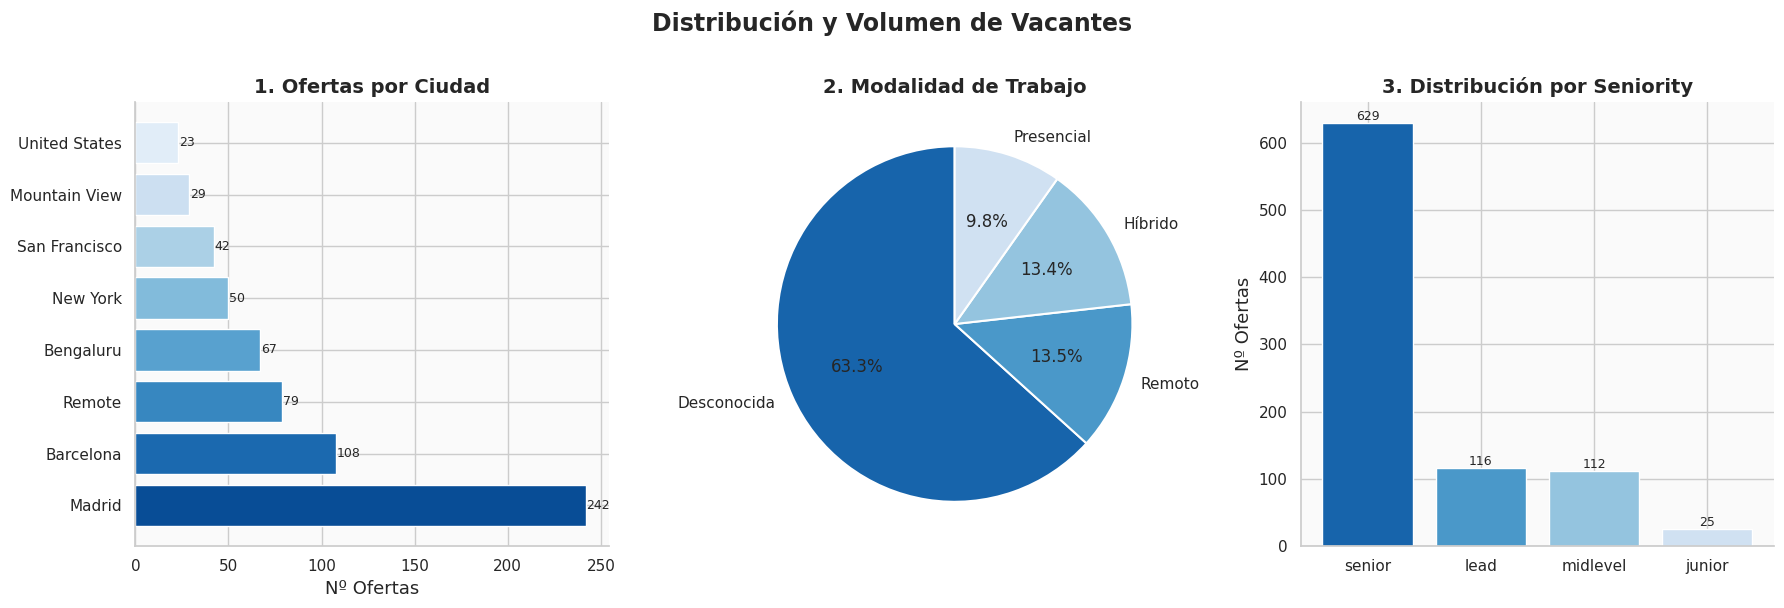

✅ Gráficos 1-3 generados.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Distribución y Volumen de Vacantes", y=1.01)

# G1: Ofertas por ciudad
if "city_clean" in df.columns:
    city_vc = df["city_clean"].value_counts().head(8)
    colors = sns.color_palette("Blues_r", len(city_vc))
    bars = axes[0].barh(city_vc.index, city_vc.values, color=colors, edgecolor="white")
    axes[0].set_title("1. Ofertas por Ciudad")
    axes[0].set_xlabel("Nº Ofertas")
    for b, v in zip(bars, city_vc.values):
        axes[0].text(b.get_width() + .3, b.get_y() + b.get_height()/2,
                     str(v), va="center", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "Ciudad no disponible", ha="center", va="center",
                 transform=axes[0].transAxes, fontsize=12); axes[0].axis("off")

# G2: Modalidad de trabajo
mod_vc = df["work_modality"].value_counts()
label_map = {"remote": "Remoto", "hybrid": "Híbrido", "onsite": "Presencial", "unknown": "Desconocida"}
mod_vc.index = mod_vc.index.map(lambda x: label_map.get(x, x))
colors2 = sns.color_palette("Blues_r", len(mod_vc))
axes[1].pie(mod_vc.values, labels=mod_vc.index, autopct="%1.1f%%",
            colors=colors2, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("2. Modalidad de Trabajo")

# G3: Seniority
if "seniority_level" in df.columns and df["seniority_level"].notna().any():
    sen_vc = df["seniority_level"].value_counts()
    axes[2].bar(sen_vc.index, sen_vc.values,
                color=sns.color_palette("Blues_r", len(sen_vc)), edgecolor="white")
    axes[2].set_title("3. Distribución por Seniority")
    axes[2].set_ylabel("Nº Ofertas")
    for b, v in zip(axes[2].patches, sen_vc.values):
        axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + .3,
                     str(v), ha="center", va="bottom", fontsize=9)
else:
    axes[2].text(0.5, 0.5, "Seniority no disponible", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=12); axes[2].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "01_distribucion_volumen.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 1-3 generados.")


## 💶 Bloque 2 — Análisis Retributivo y Salarial

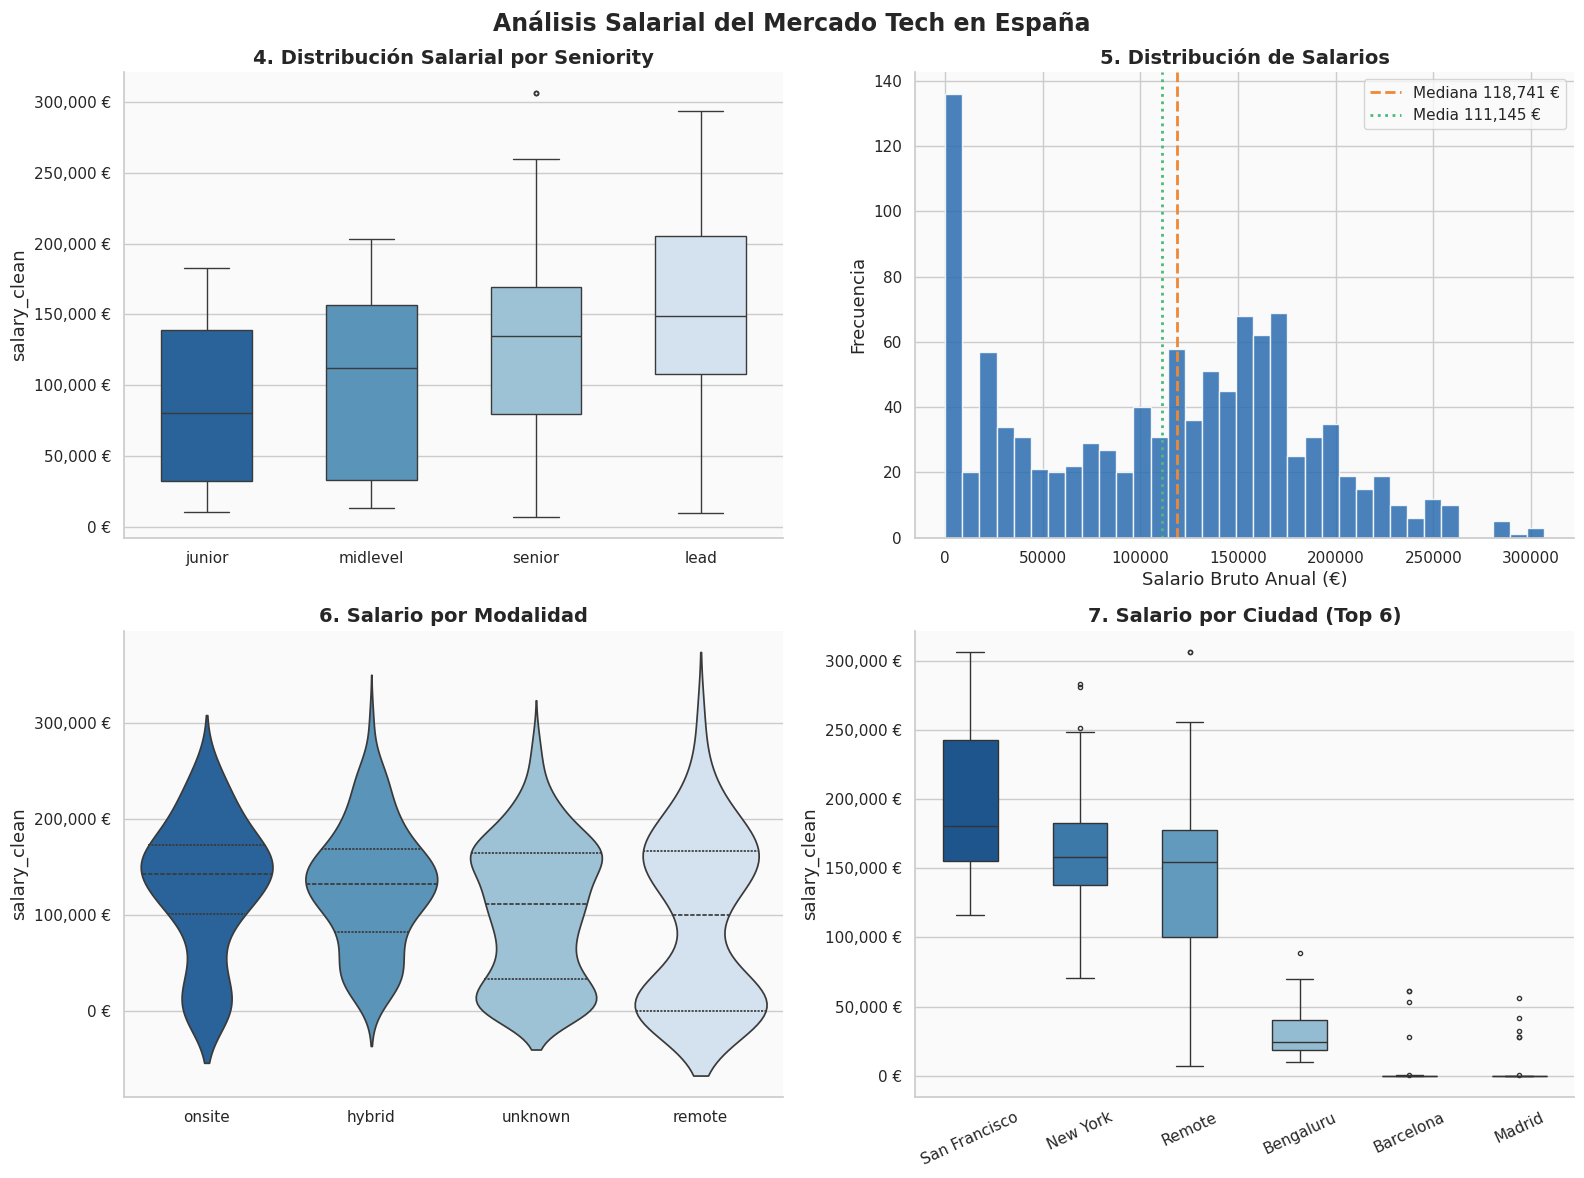

✅ Gráficos 4-7 generados.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Análisis Salarial del Mercado Tech en España")

fmt_euro = mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €")

# G4: Boxplot por seniority
if "seniority_level" in df_sal.columns and df_sal["seniority_level"].notna().any():
    order_s = df_sal.groupby("seniority_level")[SAL_COL].median().sort_values().index.tolist()
    sns.boxplot(x="seniority_level", y=SAL_COL, data=df_sal, order=order_s,
                palette="Blues_r", width=0.55, fliersize=3, ax=axes[0,0])
    axes[0,0].yaxis.set_major_formatter(fmt_euro)
    axes[0,0].set_title("4. Distribución Salarial por Seniority")
    axes[0,0].set_xlabel("")
else:
    axes[0,0].text(0.5, 0.5, "Seniority no disponible", ha="center", va="center",
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# G5: Histograma
axes[0,1].hist(df_sal[SAL_COL], bins=35, color=PAL["secondary"], edgecolor="white", alpha=0.85)
axes[0,1].axvline(df_sal[SAL_COL].median(), color=PAL["warm"], ls="--", lw=2,
                  label=f"Mediana {df_sal[SAL_COL].median():,.0f} €")
axes[0,1].axvline(df_sal[SAL_COL].mean(), color=PAL["success"], ls=":", lw=2,
                  label=f"Media {df_sal[SAL_COL].mean():,.0f} €")
axes[0,1].set_title("5. Distribución de Salarios")
axes[0,1].set_xlabel("Salario Bruto Anual (€)")
axes[0,1].set_ylabel("Frecuencia")
axes[0,1].legend()

# G6: Violín por modalidad
mod_vc6 = df_sal["work_modality"].value_counts()
valid_mods = mod_vc6[mod_vc6 >= 5].index.tolist()
df_sal6 = df_sal[df_sal["work_modality"].isin(valid_mods)].copy()
if len(valid_mods) >= 2:
    order_m = df_sal6.groupby("work_modality")[SAL_COL].median().sort_values(ascending=False).index.tolist()
    sns.violinplot(x="work_modality", y=SAL_COL, data=df_sal6, order=order_m,
                   palette="Blues_r", inner="quartile", ax=axes[1,0])
    axes[1,0].yaxis.set_major_formatter(fmt_euro)
    axes[1,0].set_title("6. Salario por Modalidad")
    axes[1,0].set_xlabel("")
else:
    axes[1,0].text(0.5, 0.5, "Datos insuficientes por modalidad", ha="center", va="center",
                   transform=axes[1,0].transAxes); axes[1,0].axis("off")

# G7: Boxplot por ciudad (Top 6)
if "city_clean" in df_sal.columns and df_sal["city_clean"].notna().any():
    top6_cities = df_sal["city_clean"].value_counts().head(6).index
    df_c = df_sal[df_sal["city_clean"].isin(top6_cities)]
    order_c = df_c.groupby("city_clean")[SAL_COL].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(x="city_clean", y=SAL_COL, data=df_c, order=order_c,
                palette="Blues_r", width=0.5, fliersize=3, ax=axes[1,1])
    axes[1,1].yaxis.set_major_formatter(fmt_euro)
    axes[1,1].set_title("7. Salario por Ciudad (Top 6)")
    axes[1,1].set_xlabel("")
    axes[1,1].tick_params(axis="x", rotation=25)
else:
    axes[1,1].text(0.5, 0.5, "Ciudad no disponible", ha="center", va="center",
                   transform=axes[1,1].transAxes); axes[1,1].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "02_analisis_salarial.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 4-7 generados.")


### 📌 Gráfico 8 — Distribución Salarial por Rol (corregida)

> **Correcciones aplicadas:**  
> - Se toman solo los **Top 15 roles** con más de 10 registros salariales.  
> - Títulos truncados a 35 caracteres para evitar solapamiento.  
> - Separación entre boxplot y stripplot; tamaño de figura aumentado.  
> - Formato de eje X en euros con separador de miles.


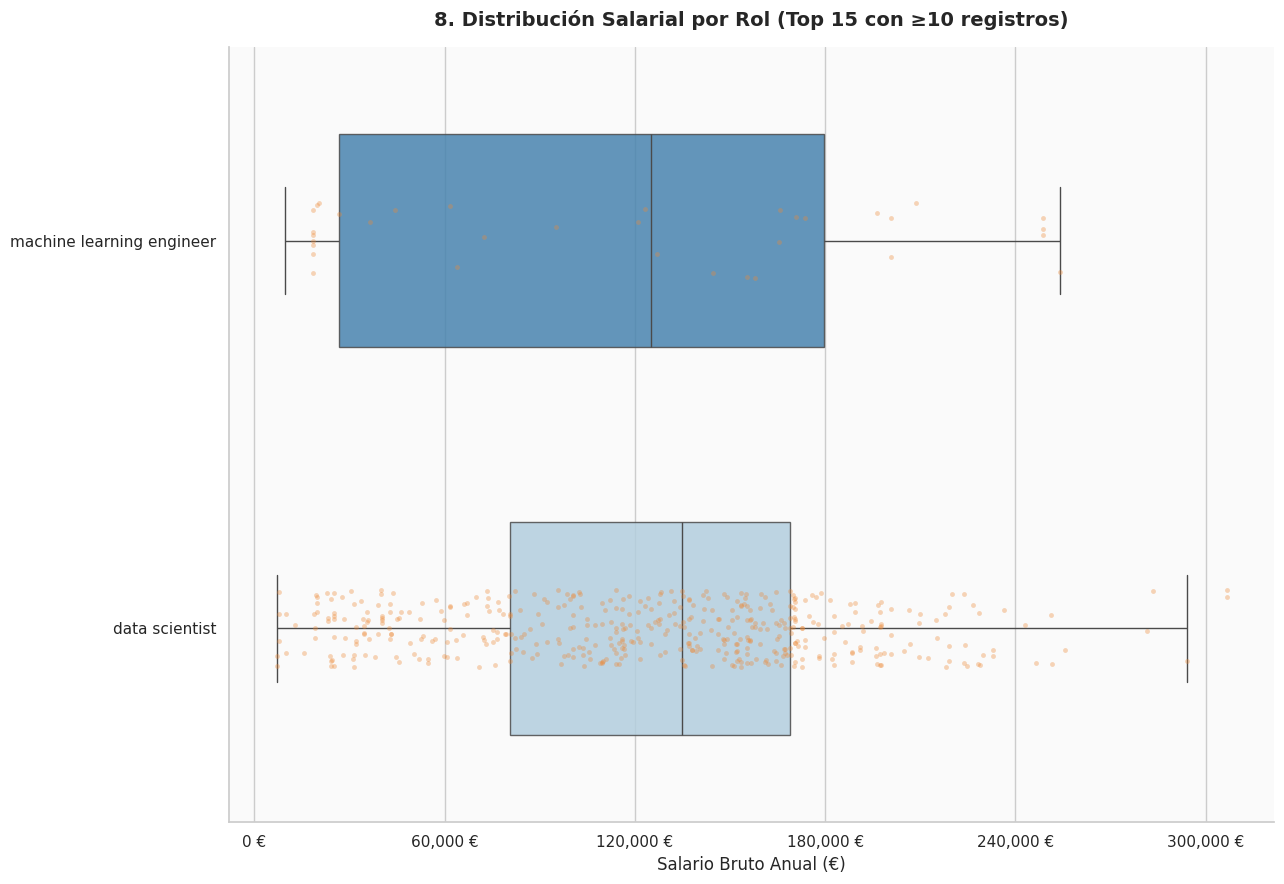

✅ Gráfico 8 generado (2 roles, 931 registros).


In [ ]:
# G8: Distribución salarial por rol — VERSIÓN CORREGIDA
if "job_title" in df_sal.columns and df_sal["job_title"].notna().any():

    # 1. Filtrar roles con al menos 10 registros salariales
    role_counts = df_sal["job_title"].value_counts()
    valid_roles = role_counts[role_counts >= 10].index
    df_r = df_sal[df_sal["job_title"].isin(valid_roles)].copy()

    # 2. Seleccionar Top 15 por mediana salarial (más interpretable que alfabético)
    top15 = (
        df_r.groupby("job_title")[SAL_COL]
        .median()
        .sort_values(ascending=True)
        .tail(15)
        .index.tolist()
    )
    df_r = df_r[df_r["job_title"].isin(top15)].copy()

    # 3. Truncar etiquetas largas
    MAX_CHARS = 35
    df_r["job_title_short"] = df_r["job_title"].str[:MAX_CHARS].where(
        df_r["job_title"].str.len() <= MAX_CHARS,
        df_r["job_title"].str[:MAX_CHARS - 1] + "…"
    )
    top15_short = [df_r[df_r["job_title"] == t]["job_title_short"].iloc[0] for t in top15]

    # 4. Figura amplia y márgenes generosos
    fig, ax = plt.subplots(figsize=(13, 9))

    # Boxplot base (sin outliers visibles — los muestra el strip)
    sns.boxplot(
        x=SAL_COL, y="job_title_short", data=df_r,
        order=top15_short, palette="Blues_r", width=0.55,
        flierprops=dict(marker="", markersize=0),   # ocultar outliers del box
        boxprops=dict(alpha=0.85),
        ax=ax
    )

    # Stripplot encima para ver distribución real de puntos
    sns.stripplot(
        x=SAL_COL, y="job_title_short",
        data=df_r.sample(min(500, len(df_r)), random_state=42),
        order=top15_short,
        color=PAL["warm"], alpha=0.35, jitter=True, size=3.5, ax=ax
    )

    ax.set_title("8. Distribución Salarial por Rol (Top 15 con ≥10 registros)",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Salario Bruto Anual (€)", fontsize=12)
    ax.set_ylabel("")

    # Eje X en euros con separador de miles
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "02b_salario_por_rol.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Gráfico 8 generado ({len(top15)} roles, {len(df_r):,} registros).")
else:
    print("ℹ️  Columna job_title no disponible en el dataset salarial.")


## 🔥 Bloque 3 — Mapas de Calor y Correlaciones

> **Correcciones aplicadas:**  
> - **G10** reemplazado por Rol × Fuente (columna `source_dataset` siempre presente, a diferencia de `remote_modality`).  
> - **G11** incluye ahora `salary_clean` + variables derivadas del pipeline (años de experiencia si existen).  
> - **G12** de skills binarias reemplazado por un mapa de calor de **Top skills × Source** calculado desde `job_skills_long.csv`.  
> - Tamaño de anotaciones y figura ajustados para que sean legibles.


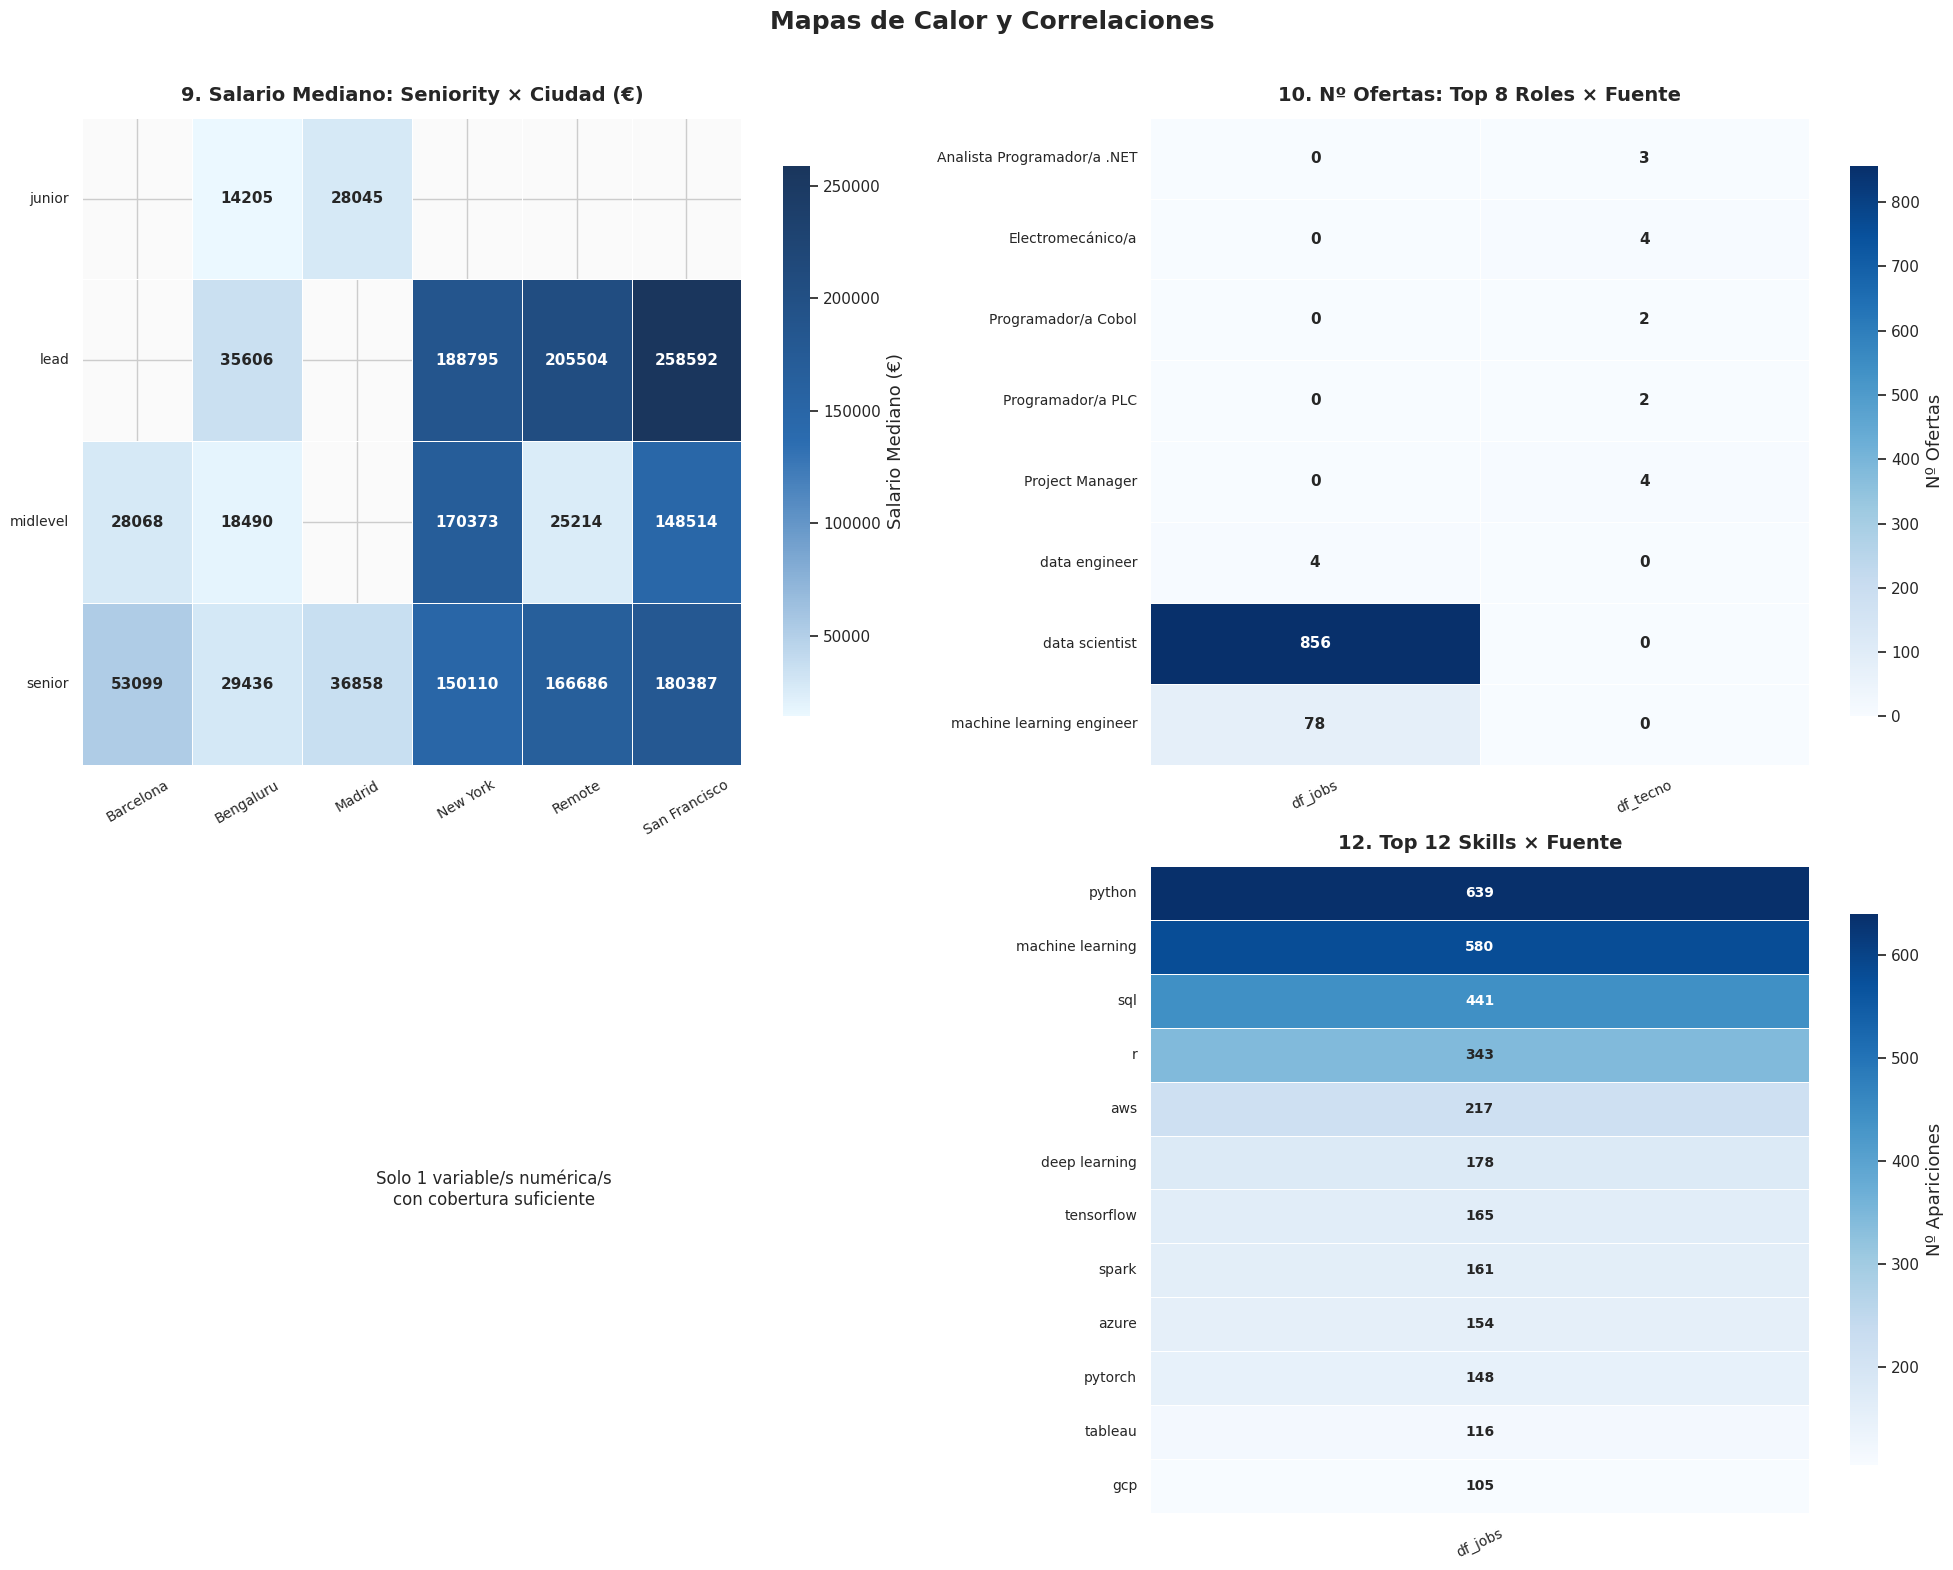

✅ Gráficos 9-12 generados.


In [ ]:
# ─────────────────────────────────────────────
# BLOQUE 3 – HEATMAPS (G9 – G12)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle("Mapas de Calor y Correlaciones", fontsize=18, fontweight="bold", y=0.98)

# ── G9: Seniority × Ciudad → Salario Mediano ──────────────────
if ("seniority_level" in df_sal.columns and df_sal["seniority_level"].notna().any()
        and "city_clean" in df_sal.columns and df_sal["city_clean"].notna().any()):

    # Tomar Top 6 ciudades con más registros salariales
    top6_c = df_sal["city_clean"].value_counts().head(6).index
    _d = df_sal[df_sal["city_clean"].isin(top6_c)]

    pivot9 = _d.pivot_table(
        values=SAL_COL, index="seniority_level",
        columns="city_clean", aggfunc="median"
    )
    pivot9 = pivot9.dropna(how="all").dropna(axis=1, how="all")

    if not pivot9.empty:
        CMAP9 = LinearSegmentedColormap.from_list("g9", [PAL["light"], PAL["secondary"], PAL["primary"]])
        g9 = sns.heatmap(
            pivot9, annot=True, fmt=".0f", cmap=CMAP9,
            linewidths=0.6, linecolor="white", ax=axes[0,0],
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            cbar_kws={"label": "Salario Mediano (€)", "shrink": 0.85},
            vmin=pivot9.min().min(), vmax=pivot9.max().max()
        )
        axes[0,0].set_title("9. Salario Mediano: Seniority × Ciudad (€)", pad=12)
        axes[0,0].set_xlabel("")
        axes[0,0].set_ylabel("")
        axes[0,0].tick_params(axis="x", rotation=30, labelsize=10)
        axes[0,0].tick_params(axis="y", rotation=0, labelsize=10)
    else:
        axes[0,0].text(0.5, 0.5, "Sin datos suficientes", ha="center", va="center",
                       transform=axes[0,0].transAxes); axes[0,0].axis("off")
else:
    axes[0,0].text(0.5, 0.5,
                   "Seniority o City\nno disponibles",
                   ha="center", va="center", fontsize=13,
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# ── G10: Rol × Fuente → Nº Ofertas ───────────────────────────
# Usa source_dataset (siempre presente) en lugar de remote_modality
if "job_title" in df.columns and "source_dataset" in df.columns:
    top8_roles = df["job_title"].value_counts().head(8).index
    _d10 = df[df["job_title"].isin(top8_roles)]
    pivot10 = _d10.pivot_table(
        values=ID_COL, index="job_title",
        columns="source_dataset", aggfunc="count", fill_value=0
    )
    if not pivot10.empty:
        sns.heatmap(
            pivot10, annot=True, fmt="d", cmap="Blues",
            linewidths=0.6, linecolor="white", ax=axes[0,1],
            annot_kws={"fontsize": 11, "fontweight": "bold"},
            cbar_kws={"label": "Nº Ofertas", "shrink": 0.85}
        )
        axes[0,1].set_title("10. Nº Ofertas: Top 8 Roles × Fuente", pad=12)
        axes[0,1].set_xlabel("")
        axes[0,1].set_ylabel("")
        axes[0,1].tick_params(axis="x", rotation=25, labelsize=10)
        axes[0,1].tick_params(axis="y", rotation=0, labelsize=10)
    else:
        axes[0,1].text(0.5, 0.5, "Sin datos", ha="center", va="center",
                       transform=axes[0,1].transAxes); axes[0,1].axis("off")
else:
    axes[0,1].text(0.5, 0.5, "job_title/source_dataset\nno disponibles",
                   ha="center", va="center", transform=axes[0,1].transAxes); axes[0,1].axis("off")

# ── G11: Correlación variables numéricas ─────────────────────
num_cols = [c for c in df.select_dtypes(include="number").columns
            if df[c].notna().sum() > len(df) * 0.2
            and "outlier" not in c.lower()
            and c != ID_COL]
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    CMAP11 = sns.diverging_palette(220, 20, as_cmap=True)
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap=CMAP11, center=0,
        linewidths=0.5, linecolor="white", ax=axes[1,0],
        annot_kws={"fontsize": 10},
        cbar_kws={"shrink": 0.8}
    )
    axes[1,0].set_title("11. Correlación Variables Numéricas", pad=12)
    axes[1,0].tick_params(axis="x", rotation=30, labelsize=9)
    axes[1,0].tick_params(axis="y", rotation=0, labelsize=9)
else:
    axes[1,0].text(0.5, 0.5,
                   f"Solo {len(num_cols)} variable/s numérica/s\ncon cobertura suficiente",
                   ha="center", va="center", fontsize=12,
                   transform=axes[1,0].transAxes); axes[1,0].axis("off")

# ── G12: Top Skills × Fuente → Nº Apariciones ────────────────
if HAS_SKILLS and df_skills is not None and "source_dataset" in df_skills.columns:
    TOP_S = 12
    top_skills_list = df_skills["skill"].value_counts().head(TOP_S).index.tolist()
    _sk = df_skills[df_skills["skill"].isin(top_skills_list)]
    pivot12 = _sk.pivot_table(
        values="job_id", index="skill",
        columns="source_dataset", aggfunc="count", fill_value=0
    )
    # Ordenar por total descendente
    pivot12 = pivot12.loc[pivot12.sum(axis=1).sort_values(ascending=False).index]
    if not pivot12.empty:
        sns.heatmap(
            pivot12, annot=True, fmt="d", cmap="Blues",
            linewidths=0.6, linecolor="white", ax=axes[1,1],
            annot_kws={"fontsize": 10, "fontweight": "bold"},
            cbar_kws={"label": "Nº Apariciones", "shrink": 0.85}
        )
        axes[1,1].set_title(f"12. Top {TOP_S} Skills × Fuente", pad=12)
        axes[1,1].set_xlabel("")
        axes[1,1].set_ylabel("")
        axes[1,1].tick_params(axis="x", rotation=25, labelsize=10)
        axes[1,1].tick_params(axis="y", rotation=0, labelsize=10)
    else:
        axes[1,1].text(0.5, 0.5, "Sin datos", ha="center", va="center",
                       transform=axes[1,1].transAxes); axes[1,1].axis("off")
else:
    axes[1,1].text(0.5, 0.5,
                   "job_skills_long.csv no disponible\n(ejecuta 02_cleaning.ipynb)",
                   ha="center", va="center", fontsize=11,
                   transform=axes[1,1].transAxes); axes[1,1].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(IMAGES_DIR / "03_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 9-12 generados.")


### 🆕 Gráfico 13 — Heatmap de Co-ocurrencia de Skills

Muestra con qué frecuencia (% de ofertas) dos skills aparecen **juntas** en la misma oferta.  
Calculado desde `job_skills_long.csv` (generado por `02_cleaning.ipynb`).


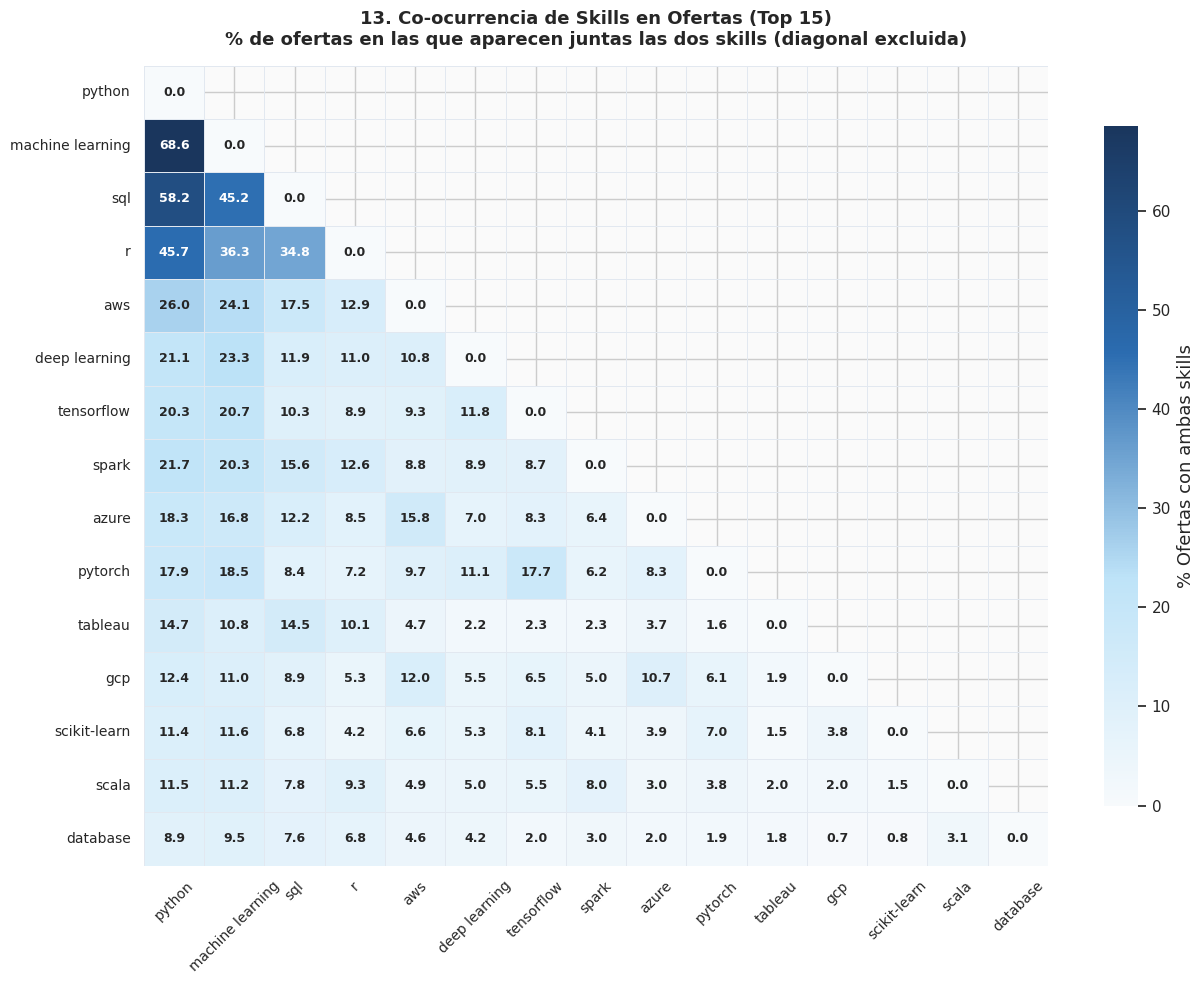

✅ Heatmap co-ocurrencia generado (739 ofertas, Top 15 skills).

🔝 Top 10 pares que más co-ocurren:


,Skill A,Skill B,Co-ocurrencia (%)
0,machine learning,python,68.60
1,sql,python,58.20
2,r,python,45.70
3,sql,machine learning,45.20
4,r,machine learning,36.30
5,r,sql,34.80
6,aws,python,26.00
7,aws,machine learning,24.10
8,deep learning,machine learning,23.30
9,spark,python,21.70


In [ ]:
if HAS_SKILLS and df_skills is not None:
    TOP_N = 15
    top_sk = df_skills["skill"].value_counts().head(TOP_N).index.tolist()
    _s = df_skills[df_skills["skill"].isin(top_sk)].copy()
    _s["present"] = 1

    pivot_sk = _s.pivot_table(
        index="job_id", columns="skill", values="present", fill_value=0
    )[top_sk]

    # Matriz de co-ocurrencia normalizada (% de todas las ofertas)
    n_jobs = pivot_sk.shape[0]
    co_mat = (pivot_sk.T @ pivot_sk) / n_jobs * 100
    co_mat = co_mat.round(1)

    # Orden por frecuencia individual (diagonal)
    freq_order = pd.Series(np.diag(co_mat), index=co_mat.columns).sort_values(ascending=False).index
    co_mat = co_mat.loc[freq_order, freq_order]

    # Diagonal a 0 para que el gradiente sea más informativo
    np.fill_diagonal(co_mat.values, 0)

    # Máscara triángulo superior
    mask_up = np.triu(np.ones_like(co_mat, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(13, 10))
    CMAP13 = LinearSegmentedColormap.from_list("cooc", ["#F7FAFC", "#BEE3F8", PAL["secondary"], PAL["primary"]])
    sns.heatmap(
        co_mat, mask=mask_up,
        annot=True, fmt=".1f", cmap=CMAP13,
        linewidths=0.5, linecolor="#E2E8F0", ax=ax,
        annot_kws={"fontsize": 9, "fontweight": "bold"},
        cbar_kws={"label": "% Ofertas con ambas skills", "shrink": 0.85},
        vmin=0
    )
    ax.set_title(
        f"13. Co-ocurrencia de Skills en Ofertas (Top {TOP_N})\n"
        "% de ofertas en las que aparecen juntas las dos skills (diagonal excluida)",
        fontsize=13, fontweight="bold", pad=15
    )
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.tick_params(axis="y", rotation=0, labelsize=10)

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "03c_heatmap_coocurrencia_skills.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Top 10 pares co-ocurrentes
    _co_stacked = (
        co_mat.where(~mask_up & ~np.eye(len(co_mat), dtype=bool))
        .stack()
        .rename_axis(index=['Skill A', 'Skill B'])
    )
    co_long = _co_stacked.reset_index(name="Co-ocurrencia (%)")
    print(f"✅ Heatmap co-ocurrencia generado ({n_jobs:,} ofertas, Top {TOP_N} skills).")
    print("\n🔝 Top 10 pares que más co-ocurren:")
    display(co_long.sort_values("Co-ocurrencia (%)", ascending=False).head(10).reset_index(drop=True))
else:
    print("ℹ️  job_skills_long.csv no disponible — ejecuta 02_cleaning.ipynb primero.")

## 🚀 Bloque 4 — Stack Tecnológico y Brecha Used vs Wanted

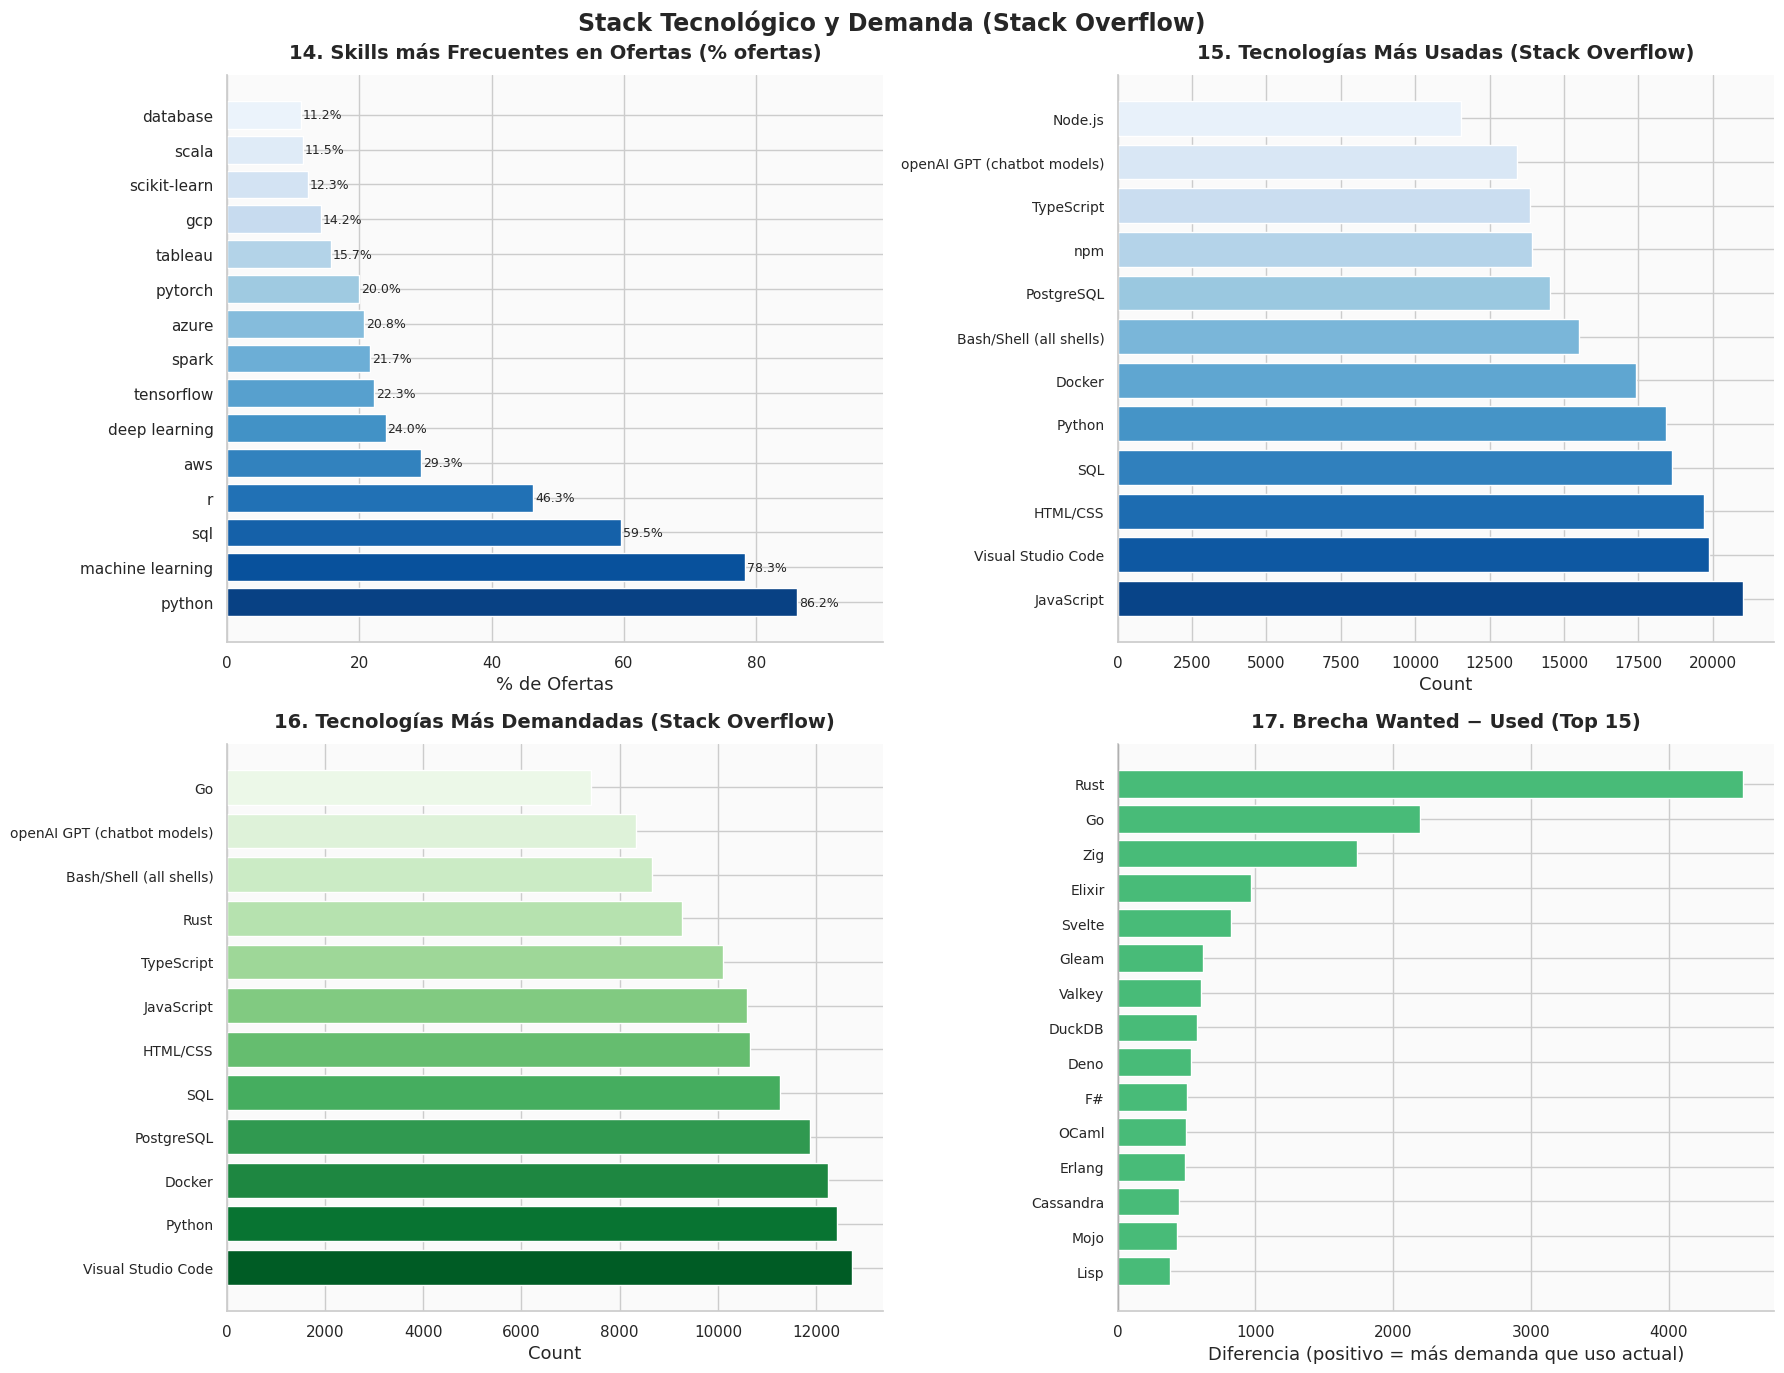

✅ Gráficos 14-17 generados.


In [ ]:
# Detectar columnas de los rankings (generados en nb02)
# Estructura: category | type | technology | count
TECH_COL = "technology"
CNT_COL  = "count"

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Stack Tecnológico y Demanda (Stack Overflow)", fontsize=17, fontweight="bold")

# G14: Top skills en ofertas (desde job_skills_long)
if HAS_SKILLS and df_skills is not None:
    top_sk_bar = df_skills["skill"].value_counts().head(15)
    pct_sk = (top_sk_bar / df_skills["job_id"].nunique() * 100).round(1)
    bars14 = axes[0,0].barh(pct_sk.index, pct_sk.values,
                             color=sns.color_palette("Blues_r", len(pct_sk)), edgecolor="white")
    axes[0,0].set_title("14. Skills más Frecuentes en Ofertas (% ofertas)", pad=12)
    axes[0,0].set_xlabel("% de Ofertas")
    axes[0,0].set_xlim(0, pct_sk.max() * 1.15)
    for b, v in zip(bars14, pct_sk.values):
        axes[0,0].text(b.get_width() + .3, b.get_y() + b.get_height()/2,
                       f"{v:.1f}%", va="center", fontsize=9)
else:
    axes[0,0].text(0.5, 0.5, "job_skills_long no disponible", ha="center", va="center",
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# G15: Top tecnologías USADAS (Stack Overflow)
top_used = df_used.sort_values(CNT_COL, ascending=False).head(12)
axes[0,1].barh(top_used[TECH_COL], top_used[CNT_COL],
               color=sns.color_palette("Blues_r", len(top_used)), edgecolor="white")
axes[0,1].set_title("15. Tecnologías Más Usadas (Stack Overflow)", pad=12)
axes[0,1].set_xlabel("Count")
axes[0,1].tick_params(axis="y", labelsize=10)

# G16: Top tecnologías DEMANDADAS (Stack Overflow)
top_wanted = df_wanted.sort_values(CNT_COL, ascending=False).head(12)
axes[1,0].barh(top_wanted[TECH_COL], top_wanted[CNT_COL],
               color=sns.color_palette("Greens_r", len(top_wanted)), edgecolor="white")
axes[1,0].set_title("16. Tecnologías Más Demandadas (Stack Overflow)", pad=12)
axes[1,0].set_xlabel("Count")
axes[1,0].tick_params(axis="y", labelsize=10)

# G17: Brecha Wanted − Used
common = set(df_used[TECH_COL]) & set(df_wanted[TECH_COL])
if common:
    df_gap = pd.merge(
        df_used[df_used[TECH_COL].isin(common)][[TECH_COL, CNT_COL]].rename(columns={CNT_COL: "used"}),
        df_wanted[df_wanted[TECH_COL].isin(common)][[TECH_COL, CNT_COL]].rename(columns={CNT_COL: "wanted"}),
        on=TECH_COL
    )
    df_gap["gap"] = df_gap["wanted"] - df_gap["used"]
    df_gap = df_gap.nlargest(15, "gap") if df_gap["gap"].max() > 0 else df_gap.nsmallest(15, "gap")
    df_gap = df_gap.sort_values("gap")
    colors17 = [PAL["success"] if v >= 0 else PAL["warm"] for v in df_gap["gap"]]
    axes[1,1].barh(df_gap[TECH_COL], df_gap["gap"], color=colors17, edgecolor="white")
    axes[1,1].axvline(0, color="black", linewidth=0.8)
    axes[1,1].set_title("17. Brecha Wanted − Used (Top 15)", pad=12)
    axes[1,1].set_xlabel("Diferencia (positivo = más demanda que uso actual)")
    axes[1,1].tick_params(axis="y", labelsize=10)
else:
    axes[1,1].text(0.5, 0.5, "Sin tecnologías comunes para brecha", ha="center", va="center",
                   transform=axes[1,1].transAxes); axes[1,1].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "04_stack_tecnologico.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 14-17 generados.")


## 📐 Bloque 5 — Análisis Estadístico Avanzado

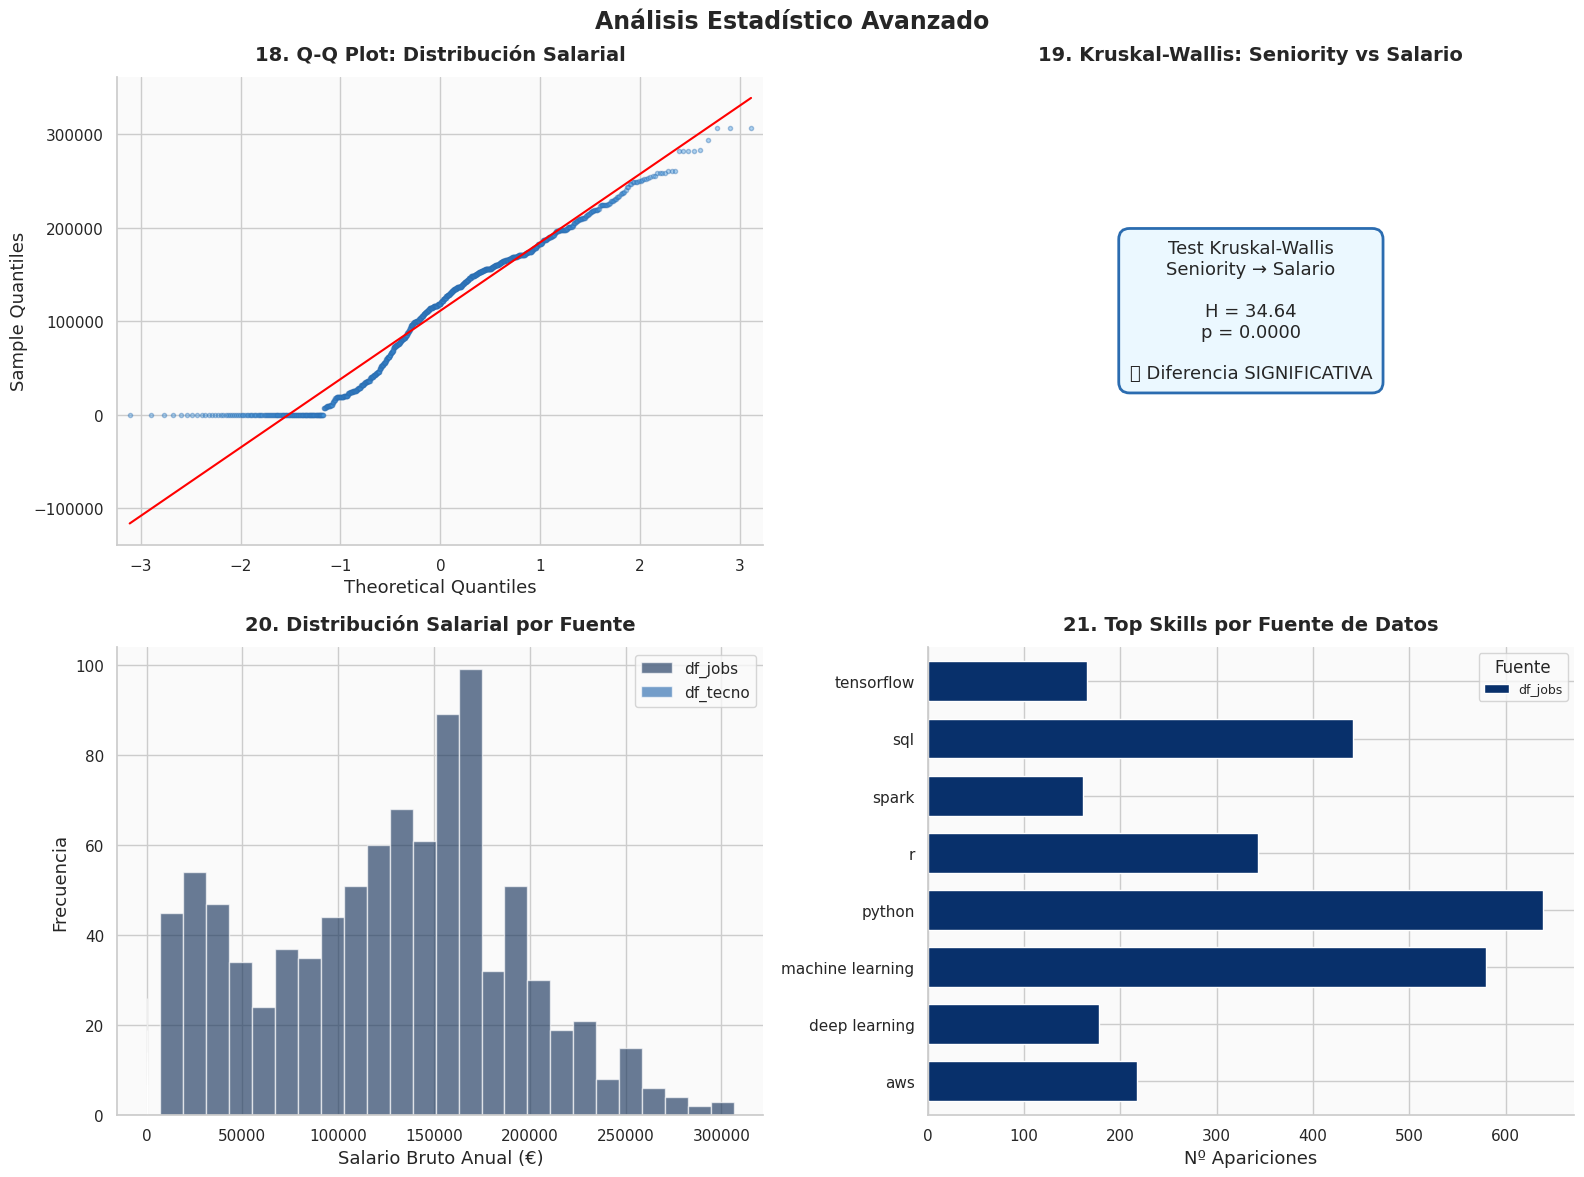

✅ Gráficos 18-21 generados.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Análisis Estadístico Avanzado")

fmt_euro = mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €")

# G18: Q-Q Plot de salarios
sal_sample = df_sal[SAL_COL].dropna()
if len(sal_sample) > 20:
    if HAS_STATSMODELS:
        sm.qqplot(sal_sample, line="s", ax=axes[0,0],
                  markerfacecolor=PAL["accent"], markeredgecolor=PAL["secondary"],
                  alpha=0.4, markersize=3)
    else:
        (osm, osr), (slope, intercept, _) = stats.probplot(sal_sample, dist="norm")
        axes[0,0].scatter(osm, osr, alpha=0.35, color=PAL["accent"], s=12)
        axes[0,0].plot(osm, slope * np.array(osm) + intercept, color=PAL["warm"], lw=1.8)
        axes[0,0].set_xlabel("Cuantiles teóricos"); axes[0,0].set_ylabel("Cuantiles muestra")
    axes[0,0].set_title("18. Q-Q Plot: Distribución Salarial", pad=12)
else:
    axes[0,0].text(0.5, 0.5, "Datos insuficientes", ha="center", va="center",
                   transform=axes[0,0].transAxes); axes[0,0].axis("off")

# G19: Kruskal-Wallis Seniority → Salario
if "seniority_level" in df_sal.columns and df_sal["seniority_level"].notna().any():
    groups = [g[SAL_COL].dropna().values
              for _, g in df_sal.groupby("seniority_level") if len(g) >= 5]
    if len(groups) >= 2:
        H, p = kruskal(*groups)
        axes[0,1].axis("off")
        sig = "✅ Diferencia SIGNIFICATIVA" if p < 0.05 else "❌ Sin diferencia significativa"
        axes[0,1].text(0.5, 0.5,
                       f"Test Kruskal-Wallis\nSeniority → Salario\n\nH = {H:.2f}\np = {p:.4f}\n\n{sig}",
                       ha="center", va="center", fontsize=13,
                       transform=axes[0,1].transAxes,
                       bbox=dict(boxstyle="round,pad=0.6", facecolor=PAL["light"],
                                 edgecolor=PAL["secondary"], linewidth=2))
        axes[0,1].set_title("19. Kruskal-Wallis: Seniority vs Salario", pad=12)
    else:
        axes[0,1].text(0.5, 0.5, "Grupos insuficientes", ha="center", va="center",
                       transform=axes[0,1].transAxes); axes[0,1].axis("off")
else:
    axes[0,1].axis("off")

# G20: Distribución por fuente (si hay más de una)
if "source_dataset" in df_sal.columns and df_sal["source_dataset"].nunique() > 1:
    for src, grp in df_sal.groupby("source_dataset"):
        axes[1,0].hist(grp[SAL_COL].dropna(), bins=25, alpha=0.65,
                       label=src, edgecolor="white")
    axes[1,0].set_title("20. Distribución Salarial por Fuente", pad=12)
    axes[1,0].set_xlabel("Salario Bruto Anual (€)")
    axes[1,0].set_ylabel("Frecuencia")
    axes[1,0].legend()
else:
    axes[1,0].hist(df_sal[SAL_COL].dropna(), bins=30,
                   color=PAL["secondary"], edgecolor="white", alpha=0.85)
    axes[1,0].set_title("20. Distribución Salarial General", pad=12)
    axes[1,0].set_xlabel("Salario Bruto Anual (€)")
    axes[1,0].set_ylabel("Frecuencia")

# G21: Skills en modalidad remota vs. presencial (si datos disponibles)
if HAS_SKILLS and df_skills is not None and "source_dataset" in df_skills.columns:
    src_skill = df_skills["source_dataset"].value_counts().head(3).index
    top5_sk = df_skills["skill"].value_counts().head(8).index
    _d21 = df_skills[df_skills["source_dataset"].isin(src_skill) & df_skills["skill"].isin(top5_sk)]
    if not _d21.empty:
        pivot21 = _d21.pivot_table(
            values="job_id", index="skill", columns="source_dataset",
            aggfunc="count", fill_value=0
        )
        pivot21.plot(kind="barh", ax=axes[1,1], colormap="Blues_r", width=0.7)
        axes[1,1].set_title("21. Top Skills por Fuente de Datos", pad=12)
        axes[1,1].set_xlabel("Nº Apariciones")
        axes[1,1].set_ylabel("")
        axes[1,1].legend(title="Fuente", fontsize=9)
    else:
        axes[1,1].axis("off")
else:
    axes[1,1].axis("off")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "05_estadistica_avanzada.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráficos 18-21 generados.")


## 🌐 Bloque 6 — Visualizaciones Interactivas (Plotly)

In [ ]:
if not HAS_PLOTLY:
    print("⚠️  Plotly no instalado. Ejecuta la celda de instalación y reinicia el entorno.")
else:
    # G22: Box interactivo Seniority × Rol
    if "seniority_level" in df_sal.columns and "job_title" in df_sal.columns:
        # Limitar a top 10 roles para legibilidad
        top10r = df_sal["job_title"].value_counts().head(10).index
        _d22 = df_sal[df_sal["job_title"].isin(top10r)]
        fig22 = px.box(
            _d22, x="seniority_level", y=SAL_COL, color="job_title",
            title="22. Distribución Salarial: Seniority × Rol (interactivo)",
            labels={SAL_COL: "Salario (€)", "seniority_level": ""},
            template="plotly_white",
        )
        fig22.update_layout(legend_title_text="Rol")
        fig22.show()

    # G23: Top ciudades interactivo
    if "city_clean" in df.columns:
        city_df = df["city_clean"].value_counts().head(10).reset_index()
        city_df.columns = ["Ciudad", "Nº Ofertas"]
        fig23 = px.bar(city_df, x="Nº Ofertas", y="Ciudad", orientation="h",
                       title="23. Top 10 Ciudades por Volumen de Ofertas",
                       template="plotly_white",
                       color="Nº Ofertas", color_continuous_scale="Blues")
        fig23.update_layout(coloraxis_showscale=False)
        fig23.show()

    # G24: Skills frecuencia interactivo
    if HAS_SKILLS and df_skills is not None:
        top_sk24 = df_skills["skill"].value_counts().head(20).reset_index()
        top_sk24.columns = ["Skill", "Count"]
        pct24 = (top_sk24["Count"] / df_skills["job_id"].nunique() * 100).round(1)
        top_sk24["% Ofertas"] = pct24
        fig24 = px.bar(top_sk24.sort_values("% Ofertas"),
                       x="% Ofertas", y="Skill", orientation="h",
                       title="24. Skills más Frecuentes en Ofertas (%)",
                       template="plotly_white",
                       color="% Ofertas", color_continuous_scale="Blues")
        fig24.show()

    print("✅ Gráficos interactivos 22-24 generados.")


✅ Gráficos interactivos 22-24 generados.


## 🏁 Bloque 7 — Panel de KPIs Ejecutivo

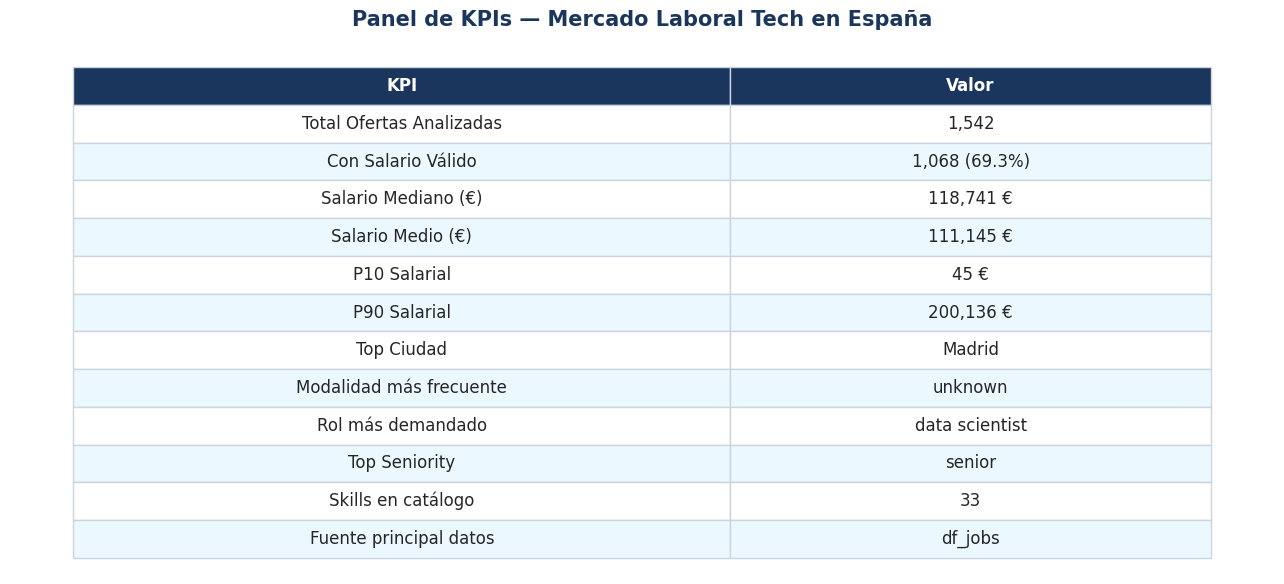


🖼️  8 gráficos exportados en alta resolución (200 DPI):
  ✅ 01_distribucion_volumen.png                        198 KB
  ✅ 02_analisis_salarial.png                           399 KB
  ✅ 02b_salario_por_rol.png                            115 KB
  ✅ 03_heatmaps.png                                    415 KB
  ✅ 03c_heatmap_coocurrencia_skills.png                307 KB
  ✅ 04_stack_tecnologico.png                           387 KB
  ✅ 05_estadistica_avanzada.png                        297 KB
  ✅ 07_kpis.png                                        150 KB

🎉 Análisis completado.


In [ ]:
kpis = {
    "Total Ofertas Analizadas":  f"{len(df):,}",
    "Con Salario Válido":        f"{len(df_sal):,} ({len(df_sal)/len(df)*100:.1f}%)",
    "Salario Mediano (€)":       f"{df_sal[SAL_COL].median():,.0f} €" if len(df_sal) > 0 else "N/D",
    "Salario Medio (€)":         f"{df_sal[SAL_COL].mean():,.0f} €"   if len(df_sal) > 0 else "N/D",
    "P10 Salarial":              f"{df_sal[SAL_COL].quantile(.10):,.0f} €" if len(df_sal) > 0 else "N/D",
    "P90 Salarial":              f"{df_sal[SAL_COL].quantile(.90):,.0f} €" if len(df_sal) > 0 else "N/D",
    "Top Ciudad":                df["city_clean"].value_counts().index[0] if "city_clean" in df.columns and df["city_clean"].notna().any() else "N/D",
    "Modalidad más frecuente":   df["work_modality"].value_counts().index[0] if "work_modality" in df.columns else "N/D",
    "Rol más demandado":         df["job_title"].value_counts().index[0][:40] if "job_title" in df.columns else "N/D",
    "Top Seniority":             df["seniority_level"].value_counts().index[0] if "seniority_level" in df.columns and df["seniority_level"].notna().any() else "N/D",
    "Skills en catálogo":        f"{df_skills['skill'].nunique():,}" if HAS_SKILLS and df_skills is not None else "N/D",
    "Fuente principal datos":    df["source_dataset"].value_counts().index[0] if "source_dataset" in df.columns else "N/D",
}

fig, ax = plt.subplots(figsize=(13, 6))
ax.axis("off")
tdata = [[k, v] for k, v in kpis.items()]
tbl = ax.table(cellText=tdata, colLabels=["KPI", "Valor"],
               cellLoc="center", loc="center", colWidths=[0.52, 0.38])
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1, 2.0)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(PAL["primary"]); cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor(PAL["light"])
    cell.set_edgecolor("#CBD5E0")

ax.set_title("Panel de KPIs — Mercado Laboral Tech en España",
             fontsize=15, fontweight="bold", pad=18, color=PAL["primary"])

plt.tight_layout()
plt.savefig(IMAGES_DIR / "07_kpis.png", dpi=200, bbox_inches="tight")
plt.show()

# Inventario de archivos exportados
files_out = sorted(IMAGES_DIR.glob("*.png"))
print(f"\n🖼️  {len(files_out)} gráficos exportados en alta resolución (200 DPI):")
for f in files_out:
    print(f"  ✅ {f.name:<50} {f.stat().st_size/1024:.0f} KB")
print("\n🎉 Análisis completado.")


## 🔄 Bloque 8 — Análisis de Reskilling y Brecha de Competencias

> **¿Qué es el reskilling?**  
> El reskilling (reconversión profesional) consiste en adquirir nuevas competencias para transitar hacia un rol diferente al actual. En el mercado tech español, perfiles de otras disciplinas (química, física, ingeniería clásica, humanidades) están migrando hacia Data Science, ML e IA.

Este bloque cuantifica:
- Las **skills más demandadas** en el mercado vs. las disponibles en perfiles de transición.
- La **brecha** entre habilidades de origen y destino para los itinerarios de reskilling más comunes.
- El **potencial de reskilling** de los roles más activos en el mercado.


In [ ]:
# ── BLOQUE 8 — Análisis de Reskilling y Brecha de Competencias ─────────────
if HAS_SKILLS and df_skills is not None:

    # ── 1. Itinerarios de reskilling más comunes ─────────────────────────────
    # Mapa: perfil origen → rol destino + skills transferibles
    reskilling_paths = {
        "Químico / Científico":    {"destino": "Data Scientist",         "transferibles": ["Python", "estadística", "SQL"]},
        "Ingeniero Clásico":       {"destino": "Data / ML Engineer",     "transferibles": ["Python", "SQL", "cloud"]},
        "Perfil Humanístico":      {"destino": "Data Analyst / BI",      "transferibles": ["Excel", "SQL", "visualización"]},
        "Desarrollador Web":       {"destino": "ML Engineer / MLOps",    "transferibles": ["Python", "Docker", "APIs"]},
        "Matemático / Estadístico":{"destino": "Data Scientist / AI",    "transferibles": ["Python", "ML", "estadística"]},
    }

    # ── 2. Skills que el mercado demanda (top 20) ────────────────────────────
    top20_demand = df_skills["skill"].value_counts().head(20)
    pct_demand   = (top20_demand / df_skills["job_id"].nunique() * 100).round(1)

    # ── 3. Gráfico A — Demanda de skills y zona de reskilling ────────────────
    RESKILL_TAGS = {
        "Python":        "core",
        "SQL":           "core",
        "Machine Learning": "core",
        "Deep Learning": "avanzada",
        "TensorFlow":    "avanzada",
        "PyTorch":       "avanzada",
        "Spark":         "data eng",
        "Kubernetes":    "mlops",
        "Docker":        "mlops",
        "Azure":         "cloud",
        "AWS":           "cloud",
        "Power BI":      "bi",
        "Tableau":       "bi",
        "Excel":         "transferible",
        "estadística":   "transferible",
        "visualización": "transferible",
    }
    # Colores por categoría
    TAG_COLORS = {
        "core":         "#2B6CB0",
        "avanzada":     "#9B2C2C",
        "data eng":     "#276749",
        "mlops":        "#744210",
        "cloud":        "#553C9A",
        "bi":           "#086F83",
        "transferible": "#2D6A4F",
    }
    bar_colors = [TAG_COLORS.get(RESKILL_TAGS.get(sk, "core"), "#4A5568") for sk in pct_demand.index]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle("Análisis de Reskilling — Brecha de Competencias en el Mercado Tech",
                 fontsize=16, fontweight="bold", y=1.01)

    # Panel izquierdo: barras de demanda con colores por categoría
    axes[0].barh(pct_demand.index[::-1], pct_demand.values[::-1],
                 color=list(reversed(bar_colors)), edgecolor="white", linewidth=0.5)
    axes[0].set_xlabel("% Ofertas que requieren la skill", fontsize=11)
    axes[0].set_title("A. Demanda de Skills (Top 20)\nColores por perfil de reskilling", pad=10, fontsize=12)
    axes[0].axvline(pct_demand.median(), color="#E53E3E", linestyle="--", linewidth=1.5,
                    label=f"Mediana ({pct_demand.median():.1f}%)")
    axes[0].legend(fontsize=10)

    # Leyenda de categorías
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=t.capitalize()) for t, c in TAG_COLORS.items()]
    axes[0].legend(handles=legend_elements, loc="lower right", fontsize=9, title="Categoría skill")

    # Panel derecho: heatmap de cobertura reskilling por itinerario
    path_labels = list(reskilling_paths.keys())
    all_transferibles = sorted({s for p in reskilling_paths.values() for s in p["transferibles"]})
    coverage_matrix = []
    for path in path_labels:
        row = [1 if skill in reskilling_paths[path]["transferibles"] else 0
               for skill in all_transferibles]
        coverage_matrix.append(row)

    import numpy as _np
    cov_df = pd.DataFrame(coverage_matrix, index=path_labels, columns=all_transferibles)

    # % de demanda de cada skill transferible en el mercado
    demand_vals = [float(pct_demand.get(sk, 0)) for sk in all_transferibles]
    weighted = cov_df.multiply(demand_vals, axis=1)

    CMAP_RSK = LinearSegmentedColormap.from_list("rsk", ["#F7FAFC", "#BEE3F8", PAL["secondary"], PAL["primary"]])
    sns.heatmap(weighted, ax=axes[1], annot=cov_df.values.astype(int),
                fmt="d", cmap=CMAP_RSK,
                linewidths=0.6, linecolor="#E2E8F0",
                cbar_kws={"label": "% Demanda de mercado (skill transferible)", "shrink": 0.85},
                annot_kws={"fontsize": 11, "fontweight": "bold"})
    axes[1].set_title("B. Cobertura de Skills Transferibles\npor Itinerario de Reskilling",
                      pad=10, fontsize=12)
    axes[1].set_xlabel("Skill Transferible", fontsize=10)
    axes[1].set_ylabel("Perfil de Origen", fontsize=10)
    axes[1].tick_params(axis="x", rotation=40, labelsize=10)
    axes[1].tick_params(axis="y", rotation=0, labelsize=10)

    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "08_reskilling.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ── 4. Tabla resumen de itinerarios ─────────────────────────────────────
    print("\n📊 Itinerarios de Reskilling detectados en el mercado tech español:\n")
    summary_rows = []
    for origen, info in reskilling_paths.items():
        transferibles = info["transferibles"]
        demanda_media = round(
            sum(float(pct_demand.get(sk, 0)) for sk in transferibles) / len(transferibles), 1
        )
        summary_rows.append({
            "Perfil Origen":       origen,
            "Rol Destino":         info["destino"],
            "Skills Transferibles": ", ".join(transferibles),
            "Demanda Media (%)":    demanda_media,
        })
    df_rsk = pd.DataFrame(summary_rows).sort_values("Demanda Media (%)", ascending=False)
    display(df_rsk.reset_index(drop=True))

    print("\n✅ Análisis de reskilling completado.")
    print("   💡 Las skills transferibles de mayor demanda reducen la brecha de entrada al mercado tech.")
else:
    print("ℹ️  job_skills_long.csv no disponible — ejecuta 02_cleaning.ipynb primero.")
